# PokeChess Demo

Demonstrates the PokeChess game engine: board layout, piece movement, attacks, damage, Foresight, evolution, and game flow. All sections include an interactive board view — use the slider to step through board states.

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import sys, os, warnings, importlib
sys.path.insert(0, os.path.dirname(os.getcwd()))
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
import ipywidgets as widgets
from IPython.display import display
import urllib.request

# Force reload so any engine changes are picked up without kernel restart
import engine.state, engine.moves, engine.rules, engine
for _m in [engine.state, engine.moves, engine.rules, engine]:
    importlib.reload(_m)

from engine import GameState, Piece, PieceType, PieceStats, PokemonType, Team, Item, PIECE_STATS
from engine.state import KING_TYPES, PAWN_TYPES, ForesightEffect
from engine.moves import get_legal_moves, Move, ActionType
from engine.rules import apply_move, is_terminal, hp_winner

print('Engine imported successfully.')

Engine imported successfully.


## Sprite Loader

Sprites are fetched from the public PokeAPI CDN and cached in `demo/sprites/`.

In [2]:
SPRITE_DIR = os.path.join(os.getcwd(), 'sprites')
os.makedirs(SPRITE_DIR, exist_ok=True)

_POKEMON_DEX = {
    PieceType.SQUIRTLE:   7,
    PieceType.CHARMANDER: 4,
    PieceType.BULBASAUR:  1,
    PieceType.MEW:        151,
    PieceType.PIKACHU:    25,
    PieceType.RAICHU:     26,
    PieceType.EEVEE:      133,
    PieceType.VAPOREON:   134,
    PieceType.FLAREON:    136,
    PieceType.LEAFEON:    470,
    PieceType.JOLTEON:    135,
    PieceType.ESPEON:     196,
    PieceType.POKEBALL:   None,
    PieceType.MASTERBALL: None,
}

SPRITE_SIZE = 88
_sprite_cache = {}


def _fetch_sprite(piece_type):
    if piece_type in _sprite_cache:
        return _sprite_cache[piece_type]
    dex = _POKEMON_DEX.get(piece_type)
    if dex is None:
        # Draw a Pokeball / Masterball circle placeholder
        img = np.zeros((SPRITE_SIZE, SPRITE_SIZE, 4), dtype=np.uint8)
        cx = cy = SPRITE_SIZE // 2
        r = SPRITE_SIZE // 2 - 4
        for y in range(SPRITE_SIZE):
            for x in range(SPRITE_SIZE):
                if (x - cx) ** 2 + (y - cy) ** 2 <= r ** 2:
                    top = y < cy
                    if piece_type == PieceType.MASTERBALL:
                        col = [130, 50, 220, 255] if top else [240, 240, 240, 255]
                    else:
                        col = [220, 50, 50, 255] if top else [240, 240, 240, 255]
                    img[y, x] = col
        _sprite_cache[piece_type] = img
        return img
    path = os.path.join(SPRITE_DIR, f'{dex}.png')
    if not os.path.exists(path):
        url = f'https://raw.githubusercontent.com/PokeAPI/sprites/master/sprites/pokemon/{dex}.png'
        urllib.request.urlretrieve(url, path)
    raw = Image.open(path).convert('RGBA')
    # Crop transparent border so sprite fills the cell
    alpha = np.array(raw)[:, :, 3]
    rows_any = np.any(alpha > 10, axis=1)
    cols_any = np.any(alpha > 10, axis=0)
    if rows_any.any() and cols_any.any():
        rmin, rmax = np.where(rows_any)[0][[0, -1]]
        cmin, cmax = np.where(cols_any)[0][[0, -1]]
        raw = raw.crop((cmin, rmin, cmax + 1, rmax + 1))
    arr = np.array(raw.resize((SPRITE_SIZE, SPRITE_SIZE), Image.NEAREST))
    _sprite_cache[piece_type] = arr
    return arr


for pt in PieceType:
    _fetch_sprite(pt)
print(f'Sprites ready ({SPRITE_SIZE}x{SPRITE_SIZE}px each).')

Sprites ready (88x88px each).


## Board Renderer

In [3]:
CELL = SPRITE_SIZE + 8
BOARD_PX = CELL * 8
_LIGHT = np.array([240, 217, 181, 255], dtype=np.uint8)
_DARK  = np.array([181, 136,  99, 255], dtype=np.uint8)
_RED_BORDER   = (220,  50,  50)
_BLUE_BORDER  = ( 50, 100, 220)
_HIGHLIGHT    = (255, 230,  50)
_PIECE_SQ_COL      = ( 90, 140, 200)
_HIGHLIGHT_ATTACK  = (220, 140,  50)  # orange
_HIGHLIGHT_FORESIGHT = ( 80, 200, 220)  # cyan


def _count_duplicates(state):
    totals, indices = {}, {}
    for r in range(8):
        for c in range(8):
            p = state.board[r][c]
            if p is None:
                continue
            key = (p.team, p.piece_type)
            totals[key] = totals.get(key, 0) + 1
            indices[(r, c)] = totals[key]
    return indices, totals


def render_board(state, highlight=None, highlight_attacks=None,
                 highlight_foresight=None, piece_sq=None, blocked_sqs=None,
                 title=None, ax=None):
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(8, 8))

    canvas = np.zeros((BOARD_PX, BOARD_PX, 4), dtype=np.uint8)

    # 1. Checkerboard
    for r in range(8):
        for c in range(8):
            y0, x0 = (7 - r) * CELL, c * CELL
            canvas[y0:y0+CELL, x0:x0+CELL] = _LIGHT if (r + c) % 2 == 0 else _DARK

    def _tint(r, c, col):
        y0, x0 = (7 - r) * CELL, c * CELL
        base = canvas[y0:y0+CELL, x0:x0+CELL].astype(float)
        ov   = np.array(list(col) + [255], dtype=float)
        canvas[y0:y0+CELL, x0:x0+CELL, :3] = np.clip(
            base[:, :, :3] * 0.50 + ov[:3] * 0.50, 0, 255).astype(np.uint8)

    # 2. Active piece square (bluish-grey)
    if piece_sq is not None:
        _tint(piece_sq[0], piece_sq[1], _PIECE_SQ_COL)

    # 3. Yellow move / orange attack / cyan foresight highlights
    for hr, hc in (highlight or []):
        _tint(hr, hc, _HIGHLIGHT)
    for hr, hc in (highlight_attacks or []):
        _tint(hr, hc, _HIGHLIGHT_ATTACK)
    for hr, hc in (highlight_foresight or []):
        _tint(hr, hc, _HIGHLIGHT_FORESIGHT)

    # 4. Sprites
    for r in range(8):
        for c in range(8):
            p = state.board[r][c]
            if p is None:
                continue
            sp = _fetch_sprite(p.piece_type).astype(float)
            y0, x0 = (7 - r) * CELL + 4, c * CELL + 4
            bg = canvas[y0:y0+SPRITE_SIZE, x0:x0+SPRITE_SIZE].astype(float)
            a  = sp[:, :, 3:4] / 255.0
            canvas[y0:y0+SPRITE_SIZE, x0:x0+SPRITE_SIZE, :3] = np.clip(
                sp[:, :, :3] * a + bg[:, :, :3] * (1 - a), 0, 255).astype(np.uint8)
            canvas[y0:y0+SPRITE_SIZE, x0:x0+SPRITE_SIZE, 3] = 255

    ax.imshow(canvas)

    # 5. Red X marks for friendly-blocked squares (drawn after imshow)
    pad = 6
    for hr, hc in (blocked_sqs or []):
        x0 = hc * CELL + pad
        y0 = (7 - hr) * CELL + pad
        x1 = (hc + 1) * CELL - pad
        y1 = (7 - hr + 1) * CELL - pad
        ax.plot([x0, x1], [y0, y1], color='red', lw=2.2, alpha=0.85, solid_capstyle='round')
        ax.plot([x0, x1], [y1, y0], color='red', lw=2.2, alpha=0.85, solid_capstyle='round')

    # 6. Coloured borders + duplicate numbers + Masterball M
    indices, totals = _count_duplicates(state)
    for r in range(8):
        for c in range(8):
            p = state.board[r][c]
            if p is None:
                continue
            ec = [v/255 for v in (_RED_BORDER if p.team == Team.RED else _BLUE_BORDER)]
            ax.add_patch(mpatches.FancyBboxPatch(
                (c * CELL + 1, (7 - r) * CELL + 1), CELL - 2, CELL - 2,
                boxstyle='square,pad=0', lw=2.5, edgecolor=ec, facecolor='none'))
            key = (p.team, p.piece_type)
            if totals.get(key, 1) > 1:
                ax.text(c * CELL + CELL - 4, (7 - r) * CELL + 12, str(indices[(r, c)]),
                        fontsize=7, fontweight='bold', color=ec, ha='right', va='top')
            if p.piece_type == PieceType.MASTERBALL:
                ax.text(c * CELL + CELL // 2, (7 - r) * CELL + int(CELL * 0.36),
                        'M', fontsize=int(CELL * 0.28), fontweight='bold',
                        color='black', ha='center', va='center')

    # 7. Axis labels
    ax.set_xticks([c * CELL + CELL // 2 for c in range(8)])
    ax.set_yticks([(7 - r) * CELL + CELL // 2 for r in range(8)])
    ax.set_xticklabels(range(8), fontsize=8)
    ax.set_yticklabels(range(8), fontsize=8)
    ax.tick_params(length=0)
    ax.set_xlim(0, BOARD_PX)
    ax.set_ylim(BOARD_PX, 0)
    ax.set_title(title or f'Turn {state.turn_number}  |  Active: {state.active_player.name}',
                 fontsize=14, pad=8)

    if standalone:
        plt.tight_layout()
        plt.show()


def render_hp_bars(state, ax):
    from collections import Counter
    _SKIP = {PieceType.POKEBALL, PieceType.MASTERBALL}
    red_ps  = [state.board[r][c] for r in range(8) for c in range(8)
               if state.board[r][c] and state.board[r][c].team == Team.RED
               and state.board[r][c].piece_type not in _SKIP]
    blue_ps = [state.board[r][c] for r in range(8) for c in range(8)
               if state.board[r][c] and state.board[r][c].team == Team.BLUE
               and state.board[r][c].piece_type not in _SKIP]

    bars = []
    for pieces, color in [(red_ps, '#DC3232'), (blue_ps, '#3264DC')]:
        counts = Counter(p.piece_type for p in pieces)
        idx = {}
        for p in pieces:
            if counts[p.piece_type] > 1:
                idx[p.piece_type] = idx.get(p.piece_type, 0) + 1
                name = f'{p.piece_type.name.title()} {idx[p.piece_type]}'
            else:
                name = p.piece_type.name.title()
            max_hp = PIECE_STATS[p.piece_type].max_hp
            frac   = p.current_hp / max_hp
            bars.append((name, frac, p.current_hp, max_hp, color))

    if not bars:
        ax.axis('off')
        return

    for i, (name, frac, hp, max_hp, color) in enumerate(reversed(bars)):
        ax.barh(i, 1.0,  height=0.55, color=color, alpha=0.15)
        ax.barh(i, frac, height=0.55, color=color, alpha=0.85)
        ax.text(-0.03, i, name,             ha='right', va='center', fontsize=9)
        ax.text( 1.03, i, f'{hp}/{max_hp}', ha='left',  va='center', fontsize=9)

    ax.set_xlim(-0.45, 1.45)
    ax.set_ylim(-0.6, len(bars) - 0.4)
    ax.set_xticks([0, 0.5, 1.0])
    ax.set_xticklabels(['0%', '50%', '100%'], fontsize=8)
    ax.set_yticks([])
    for spine in ('top', 'right', 'left'):
        ax.spines[spine].set_visible(False)
    ax.set_title('HP', fontsize=11)


print('Renderer + HP bars ready.')


Renderer + HP bars ready.


## Interactive Viewer

In [4]:
def _render_frame(state, hl, piece_sq, blocked_sqs, label, show_hp, figsize):
    if show_hp:
        fig = plt.figure(figsize=(figsize[0] + 4, figsize[1]))
        gs  = fig.add_gridspec(1, 2, width_ratios=[3, 1], wspace=0.35)
        ax_b = fig.add_subplot(gs[0])
        ax_h = fig.add_subplot(gs[1])
        render_board(state, highlight=hl, piece_sq=piece_sq, blocked_sqs=blocked_sqs,
                     title=label, ax=ax_b)
        render_hp_bars(state, ax_h)
    else:
        fig, ax = plt.subplots(figsize=figsize)
        render_board(state, highlight=hl, piece_sq=piece_sq, blocked_sqs=blocked_sqs,
                     title=label, ax=ax)
    plt.tight_layout()
    plt.show()


def show_states(states_labels, highlight_fn=None, piece_sq_fn=None, blocked_fn=None,
                show_hp=False, figsize=(8, 8)):
    n = len(states_labels)
    if n == 0:
        return
    if n == 1:
        state, label = states_labels[0]
        hl = highlight_fn(state, 0) if highlight_fn else None
        ps = piece_sq_fn(state, 0) if piece_sq_fn else None
        bl = blocked_fn(state, 0)  if blocked_fn  else None
        _render_frame(state, hl, ps, bl, label, show_hp, figsize)
        return

    out    = widgets.Output()
    slider = widgets.IntSlider(
        value=1, min=1, max=n, step=1, description='Turn:',
        continuous_update=False,
        style={'description_width': '50px'},
        layout=widgets.Layout(width='480px'))
    btn_prev = widgets.Button(description='\u25c4',
                              layout=widgets.Layout(width='44px', height='32px'))
    btn_next = widgets.Button(description='\u25ba',
                              layout=widgets.Layout(width='44px', height='32px'))

    def _draw(idx):
        state, label = states_labels[idx]
        hl = highlight_fn(state, idx) if highlight_fn else None
        ps = piece_sq_fn(state, idx) if piece_sq_fn else None
        bl = blocked_fn(state, idx)  if blocked_fn  else None
        with out:
            out.clear_output(wait=True)
            _render_frame(state, hl, ps, bl, label, show_hp, figsize)

    def _on_slider(change):
        _draw(change['new'] - 1)

    def _on_prev(_):
        if slider.value > 1:
            slider.value -= 1

    def _on_next(_):
        if slider.value < n:
            slider.value += 1

    slider.observe(_on_slider, names='value')
    btn_prev.on_click(_on_prev)
    btn_next.on_click(_on_next)

    controls = widgets.HBox([btn_prev, slider, btn_next],
                            layout=widgets.Layout(align_items='center'))
    display(widgets.VBox([controls, out]))
    _draw(0)


print('Interactive viewer ready.')


Interactive viewer ready.


## Helpers

In [5]:
def empty_state(active=Team.RED, turn=1):
    board = [[None] * 8 for _ in range(8)]
    return GameState(board=board, active_player=active, turn_number=turn,
                     pending_foresight={Team.RED: None, Team.BLUE: None})

def place(state, pt, team, row, col):
    p = Piece.create(pt, team, row, col)
    state.board[row][col] = p
    return p

def apply_det(state, row, col, action_type, target_row, target_col, **kw):
    move = Move(piece_row=row, piece_col=col, action_type=action_type,
                target_row=target_row, target_col=target_col, **kw)
    return apply_move(state, move)[0][0]

def moves_from(state, row, col):
    return [m for m in get_legal_moves(state) if m.piece_row == row and m.piece_col == col]

def get_friendly_blocked(state, row, col):
    piece = state.board[row][col]
    if piece is None:
        return []
    ROOK_D   = [(0,1),(0,-1),(1,0),(-1,0)]
    BISHOP_D = [(1,1),(1,-1),(-1,1),(-1,-1)]
    KING_D   = [(dr,dc) for dr in (-1,0,1) for dc in (-1,0,1) if (dr,dc)!=(0,0)]
    KNIGHT_D = [(2,1),(2,-1),(-2,1),(-2,-1),(1,2),(1,-2),(-1,2),(-1,-2)]
    PIKA_EXT = [(3,1),(3,-1),(-3,1),(-3,-1),(1,3),(1,-3),(-1,3),(-1,-3)]
    fwd = 1 if piece.team == Team.RED else -1
    blocked = []

    def slide(dirs, max_steps=8):
        for dr, dc in dirs:
            r, c = row + dr, col + dc
            for _ in range(max_steps):
                if not (0 <= r < 8 and 0 <= c < 8): break
                occ = state.board[r][c]
                if occ is not None:
                    if occ.team == piece.team:
                        blocked.append((r, c))
                    break
                r += dr; c += dc

    def jumps(deltas):
        for dr, dc in deltas:
            r, c = row + dr, col + dc
            if 0 <= r < 8 and 0 <= c < 8:
                occ = state.board[r][c]
                if occ is not None and occ.team == piece.team:
                    blocked.append((r, c))

    pt = piece.piece_type
    if pt == PieceType.SQUIRTLE:
        slide(ROOK_D)
    elif pt == PieceType.BULBASAUR:
        slide(BISHOP_D)
    elif pt == PieceType.MEW:
        slide(ROOK_D + BISHOP_D)
    elif pt == PieceType.CHARMANDER:
        jumps(KNIGHT_D)
    elif pt == PieceType.POKEBALL:
        slide([(fwd,0),(0,1),(0,-1)], 2)
        slide([(fwd,1),(fwd,-1)], 1)
    elif pt == PieceType.MASTERBALL:
        slide([(fwd,0),(0,1),(0,-1),(-fwd,0)], 2)
        slide([(fwd,1),(fwd,-1),(-fwd,1),(-fwd,-1)], 1)
    elif pt == PieceType.PIKACHU:
        jumps(KING_D); jumps(PIKA_EXT)
    else:
        jumps(KING_D)
    return blocked

print('Helpers ready.')


Helpers ready.


---
## Section 1 — Starting Board

RED (Pikachu side) occupies rows 0–1; BLUE (Eevee side) occupies rows 6–7. Numbers in the corner distinguish identical pieces on the same side.

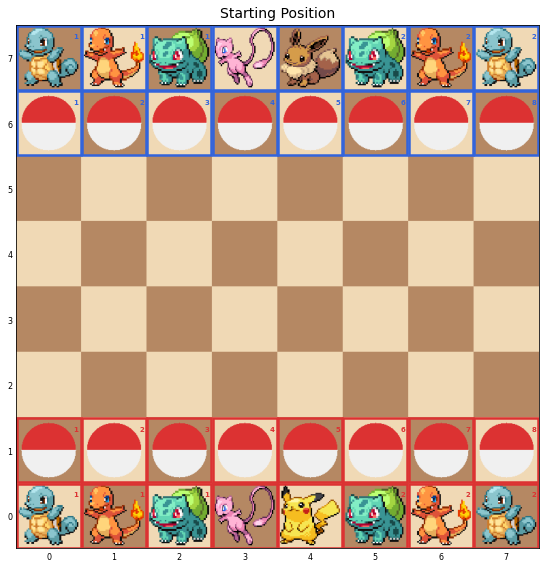

In [6]:
render_board(GameState.new_game(), title='Starting Position')

---
## Section 2 — Legal Move Inspection

Yellow highlights = legal move targets for the selected piece. Use the slider to view different pieces.

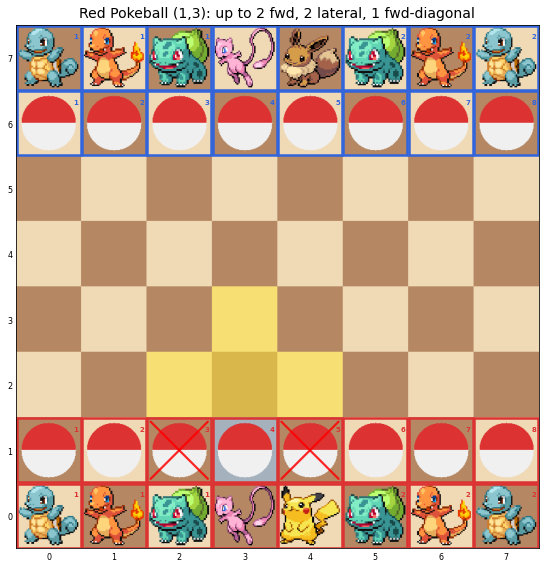

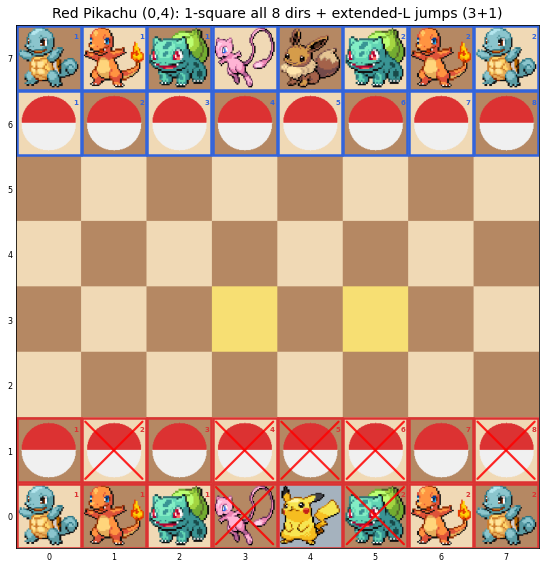

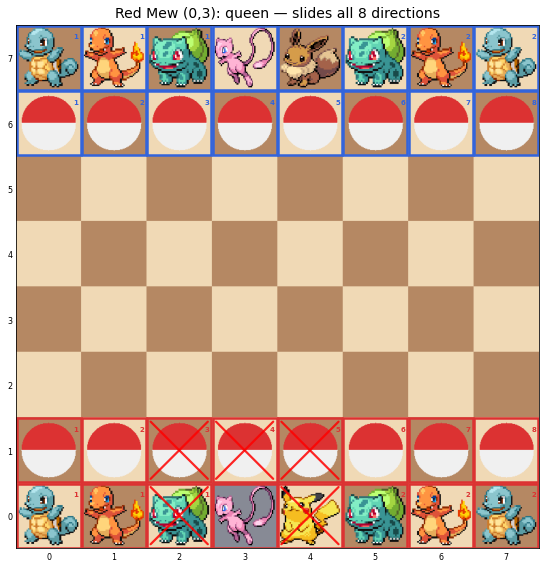

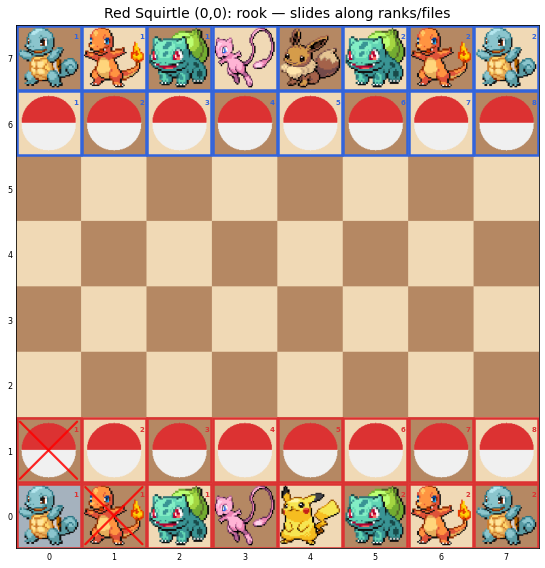

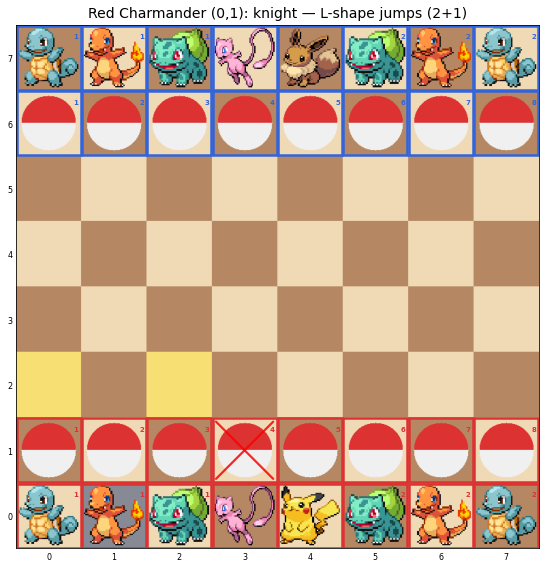

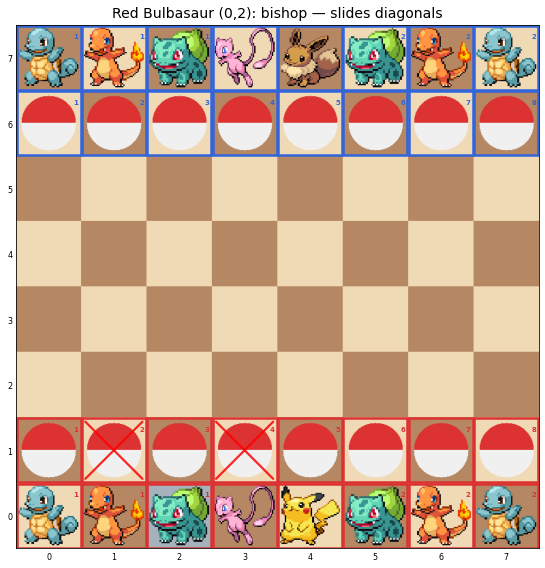

In [7]:
s = GameState.new_game()
pieces = [
    (1, 3, 'Red Pokeball (1,3): up to 2 fwd, 2 lateral, 1 fwd-diagonal'),
    (0, 4, 'Red Pikachu (0,4): 1-square all 8 dirs + extended-L jumps (3+1)'),
    (0, 3, 'Red Mew (0,3): queen — slides all 8 directions'),
    (0, 0, 'Red Squirtle (0,0): rook — slides along ranks/files'),
    (0, 1, 'Red Charmander (0,1): knight — L-shape jumps (2+1)'),
    (0, 2, 'Red Bulbasaur (0,2): bishop — slides diagonals'),
]
for row, col, lbl in pieces:
    mvs = moves_from(s, row, col)
    hl  = [(m.target_row, m.target_col) for m in mvs
           if m.action_type in (ActionType.MOVE, ActionType.ATTACK)]
    bl  = get_friendly_blocked(s, row, col)
    render_board(s, highlight=hl, piece_sq=(row, col), blocked_sqs=bl, title=lbl)

---
## Section 3 — Pokeball Movement

Pokeballs differ from chess pawns:
- Move **up to 2 squares forward** (not limited to 1 after leaving home row)
- Move **up to 2 squares laterally** (left or right)
- Move **1 square forward-diagonally**
- **No backward movement** (Masterball adds that)

All these also apply as attack directions if an enemy occupies that square.

In [8]:
# Pokeball at (3,3), Eevee at (5,4).
# On RED's turn at (3,3): reachable = fwd2(5,3), fwd1(4,3), right2(3,5), right1(3,4),
#   left2(3,1), left1(3,2), fwd-right(4,4), fwd-left(4,2). Eevee at (5,4): NOT in range.
pb3 = empty_state(active=Team.RED, turn=1)
place(pb3, PieceType.POKEBALL, Team.RED,  3, 3)
place(pb3, PieceType.EEVEE,   Team.BLUE,  5, 4)

hl_start = [(m.target_row, m.target_col) for m in moves_from(pb3, 3, 3)
            if m.action_type in (ActionType.MOVE, ActionType.ATTACK)]
bl_start = get_friendly_blocked(pb3, 3, 3)

# T1 RED: Pokeball advances fwd2 to (5,3) -- chasing
s1 = apply_det(pb3, 3, 3, ActionType.MOVE, 5, 3)
# T1b BLUE: Eevee steps back-right to (4,4) -- slips behind the pokeball's line of advance
#   From (5,3), pokeball can reach (5,4),(5,5),(6,4),(7,3),(6,3),(5,1),(5,2),(6,2).
#   (4,4) is NOT reachable (pokeball cannot go backward). Eevee is safe next RED turn.
s2 = apply_det(s1,  5, 4, ActionType.MOVE, 4, 4)
# T2 RED: Pokeball moves fwd-right to (6,4) -- still advancing
s3 = apply_det(s2,  5, 3, ActionType.MOVE, 6, 4)
# T2b BLUE: Eevee retreats to (3,4) -- now safely behind the pokeball
#   Pokeball at (6,4) can only go forward (toward row 7) or sideways. (3,4) is unreachable.
s4 = apply_det(s3,  4, 4, ActionType.MOVE, 3, 4)

show_states([
    (pb3, 'Pokeball at (3,3) -- yellow: legal moves  |  Eevee at (5,4) is out of range'),
    (s1,  'Pokeball advances fwd x2 to (5,3) -- closing in'),
    (s2,  'Eevee steps to (4,4) -- behind the Pokeball, out of reach'),
    (s3,  'Pokeball pushes forward-right to (6,4) -- still chasing'),
    (s4,  'Eevee retreats to (3,4) -- safely past the Pokeball; Pokeball cannot go backward'),
], highlight_fn=lambda st, i: hl_start if i == 0 else [],
   piece_sq_fn=lambda st, i: (3, 3) if i == 0 else None,
   blocked_fn=lambda st, i: bl_start if i == 0 else [])

---
## Section 4 — Squirtle (Rook) Movement

Squirtle slides any number of squares along ranks or files. Friendly pieces block it; the first enemy on a ray can be attacked but the ray goes no further.

In [9]:
sq_s = empty_state()
place(sq_s, PieceType.PIKACHU,    Team.RED,  0, 4)
place(sq_s, PieceType.EEVEE,      Team.BLUE, 7, 4)
sq   = place(sq_s, PieceType.SQUIRTLE,   Team.RED,  4, 1)
b_ch = place(sq_s, PieceType.CHARMANDER, Team.BLUE, 4, 5)

mvs_sq = [m for m in moves_from(sq_s, 4, 1)
          if m.action_type in (ActionType.MOVE, ActionType.ATTACK)]
sq_tgts = [(m.target_row, m.target_col) for m in mvs_sq]
bl_sq   = get_friendly_blocked(sq_s, 4, 1)

# Squirtle slides right along rank 4 and captures Charmander directly
sq2 = apply_det(sq_s, 4, 1, ActionType.ATTACK, 4, 5)

show_states([
    (sq_s, 'Squirtle at (4,1) — yellow: legal moves\nSquirtle can reach and attack Charmander at (4,5) in one action'),
    (sq2,  'Squirtle Hydro Pump — 200 dmg (Water 2x Fire) — KO\nSquirtle occupies the captured square (4,5)'),
], highlight_fn=lambda st, i: sq_tgts if i == 0 else [],
   piece_sq_fn=lambda st, i: (4, 1) if i == 0 else None,
   blocked_fn=lambda st, i: bl_sq if i == 0 else [])

---
## Section 5 -- Combat: Damage and KO

Each piece knows one named attack. Base damage is **100** for all standard attacks.
Type multipliers: Water > Fire > Grass > Water (2x/0.5x). Same or unrelated types = 1x.

| Piece(s) | Move | Type | Base dmg |
|---|---|---|---|
| Squirtle, Vaporeon | **Hydro Pump** | Water | 100 |
| Charmander, Flareon | **Fire Blast** | Fire | 100 |
| Bulbasaur, Leafeon | **Solar Beam** | Grass | 100 |
| Pikachu, Raichu, Jolteon | **Thunderbolt** | Electric | 100 |
| Eevee | **Quick Attack** | Normal | 50 |
| Mew, Espeon | **Foresight** | Psychic | 120 (fixed, delayed) |

Mew also has **three direct attack slots** using typed moves (Fire Blast / Hydro Pump / Solar Beam),
each with 100 base damage but a different type for the matchup calculation.
Foresight is Mew's **fourth move** (ActionType.FORESIGHT, already shown in Section 8).

Strategic value: Mew can choose to go **lethal** (pick the super-effective type -> 200 dmg KO)
or **non-lethal** (pick a resisted type -> 50 dmg), staying in place instead of being forced
to occupy the captured square.

In [10]:
from engine.rules import _calc_damage

_MEW_MOVE_NAMES = {0: 'Fire Blast', 1: 'Hydro Pump', 2: 'Solar Beam'}

def dmg(at, dt, slot=None):
    a = Piece.create(at, Team.RED,  0, 0); a.held_item = Item.NONE
    d = Piece.create(dt, Team.BLUE, 0, 1); d.held_item = Item.NONE
    return _calc_damage(a, d, slot)

print('Damage reference (base 100 each):')
rows = [
    ('Hydro Pump',  'vs Charmander',  PieceType.SQUIRTLE,   PieceType.CHARMANDER, None, '2.0x Water->Fire'),
    ('Hydro Pump',  'vs Bulbasaur',   PieceType.SQUIRTLE,   PieceType.BULBASAUR,  None, '0.5x Water->Grass'),
    ('Hydro Pump',  'vs Pikachu',     PieceType.SQUIRTLE,   PieceType.PIKACHU,    None, '1.0x Water->Electric'),
    ('Fire Blast',  'vs Bulbasaur',   PieceType.CHARMANDER, PieceType.BULBASAUR,  None, '2.0x Fire->Grass'),
    ('Solar Beam',  'vs Squirtle',    PieceType.BULBASAUR,  PieceType.SQUIRTLE,   None, '2.0x Grass->Water'),
    ('Thunderbolt', 'vs Squirtle',    PieceType.PIKACHU,    PieceType.SQUIRTLE,   None, '1.0x Electric->Water'),
    ('Quick Attack','vs Squirtle',    PieceType.EEVEE,      PieceType.SQUIRTLE,   None, '1.0x Normal->Water'),
]
for move, target, at, dt, slot, note in rows:
    print(f'  {move:<14} {target:<16}: {dmg(at, dt, slot):>4} dmg  ({note})')

print()
print("  Foresight (Mew/Espeon): 120 dmg fixed, resolves on caster's next turn")
print()
print('Mew moves (each 100 base, typed to the move):')
for slot, name in _MEW_MOVE_NAMES.items():
    print(f'  Move {slot} {name:<14}:'
          f'  {dmg(PieceType.MEW, PieceType.SQUIRTLE, slot):>3} dmg vs Water'
          f'  |  {dmg(PieceType.MEW, PieceType.CHARMANDER, slot):>3} dmg vs Fire'
          f'  |  {dmg(PieceType.MEW, PieceType.BULBASAUR, slot):>3} dmg vs Grass')
print('  Move 3 Foresight      :  120 dmg fixed (delayed, ActionType.FORESIGHT)')

Damage reference (base 100 each):
  Hydro Pump     vs Charmander   :  200 dmg  (2.0x Water->Fire)
  Hydro Pump     vs Bulbasaur    :   50 dmg  (0.5x Water->Grass)
  Hydro Pump     vs Pikachu      :  100 dmg  (1.0x Water->Electric)
  Fire Blast     vs Bulbasaur    :  200 dmg  (2.0x Fire->Grass)
  Solar Beam     vs Squirtle     :  200 dmg  (2.0x Grass->Water)
  Thunderbolt    vs Squirtle     :  100 dmg  (1.0x Electric->Water)
  Quick Attack   vs Squirtle     :   50 dmg  (1.0x Normal->Water)

  Foresight (Mew/Espeon): 120 dmg fixed, resolves on caster's next turn

Mew moves (each 100 base, typed to the move):
  Move 0 Fire Blast    :   50 dmg vs Water  |   50 dmg vs Fire  |  200 dmg vs Grass
  Move 1 Hydro Pump    :   50 dmg vs Water  |  200 dmg vs Fire  |   50 dmg vs Grass
  Move 2 Solar Beam    :  200 dmg vs Water  |   50 dmg vs Fire  |   50 dmg vs Grass
  Move 3 Foresight      :  120 dmg fixed (delayed, ActionType.FORESIGHT)


In [11]:
# Multi-step combat scenario
cs = empty_state()
place(cs, PieceType.PIKACHU,    Team.RED,  0, 4)
place(cs, PieceType.EEVEE,      Team.BLUE, 7, 4)
r_sq  = place(cs, PieceType.SQUIRTLE,   Team.RED,  3, 0)
b_ch  = place(cs, PieceType.CHARMANDER, Team.BLUE, 3, 3)
b_bu  = place(cs, PieceType.BULBASAUR,  Team.BLUE, 0, 0)
r_mew = place(cs, PieceType.MEW,        Team.RED,  6, 6)

# Turn 1 (RED): Squirtle Hydro Pump -> Charmander (3,3)
cs2 = apply_det(cs, 3, 0, ActionType.ATTACK, 3, 3)
# Turn 2 (BLUE): Bulbasaur Solar Beam -> Squirtle at (3,3)
cs3 = apply_det(cs2, 0, 0, ActionType.ATTACK, 3, 3)
# Turn 3 (RED): Mew Fire Blast (slot 0, Fire 2x Grass) -> Bulbasaur at (3,3)
cs4 = apply_det(cs3, 6, 6, ActionType.ATTACK, 3, 3, move_slot=0)

show_states([
    (cs,  'Setup: RED Squirtle(3,0) + Mew(6,6);  BLUE Charmander(3,3) + Bulbasaur(0,0)'),
    (cs2, 'T1 -- Squirtle Hydro Pump -> Charmander: 200 dmg (Water 2x Fire) -> KO'),
    (cs3, 'T2 -- Bulbasaur Solar Beam -> Squirtle: 200 dmg (Grass 2x Water) -> KO'),
    (cs4, 'T3 -- Mew Fire Blast -> Bulbasaur: 200 dmg (Fire 2x Grass) -> KO'),
], show_hp=True)

---
## Section 6 — Items (Evolution Only)

Held items gate evolution but have **no effect on damage**. Pokeballs and Masterballs cannot hold items and therefore cannot trade.

In [12]:
for item in [Item.NONE, Item.WATERSTONE, Item.FIRESTONE]:
    a = Piece.create(PieceType.SQUIRTLE, Team.RED, 0, 0); a.held_item = item
    d = Piece.create(PieceType.CHARMANDER, Team.BLUE, 0, 1)
    print(f'  Squirtle ({item.name:<12}) -> Charmander: {_calc_damage(a, d)} dmg  (identical regardless of item)')

# Confirm Pokeball has no trade moves
no_trade = empty_state()
place(no_trade, PieceType.POKEBALL, Team.RED, 3, 3)
place(no_trade, PieceType.SQUIRTLE, Team.RED, 3, 4)
pb_mvs = moves_from(no_trade, 3, 3)
trade_mvs = [m for m in pb_mvs if m.action_type == ActionType.TRADE]
print(f'\nPokeball trade moves: {len(trade_mvs)}  (Pokeballs cannot hold items -> no trades)')


  Squirtle (NONE        ) -> Charmander: 200 dmg  (identical regardless of item)
  Squirtle (WATERSTONE  ) -> Charmander: 200 dmg  (identical regardless of item)
  Squirtle (FIRESTONE   ) -> Charmander: 200 dmg  (identical regardless of item)

Pokeball trade moves: 0  (Pokeballs cannot hold items -> no trades)


---
## Section 7 — Stochastic Pokeball Capture

Two outcomes at p=0.5 each. Pikachu/Raichu are immune (deterministic fail). Masterball always captures.

Pokeball vs Squirtle: 2 outcomes at p=0.5 each
  p=0.5: Capture -- Pokeball occupies (3,4)
  p=0.5: Fail -- Squirtle survives

Pokeball vs Blue Pikachu: 1 outcome (p=1.0) -- Pikachu is immune


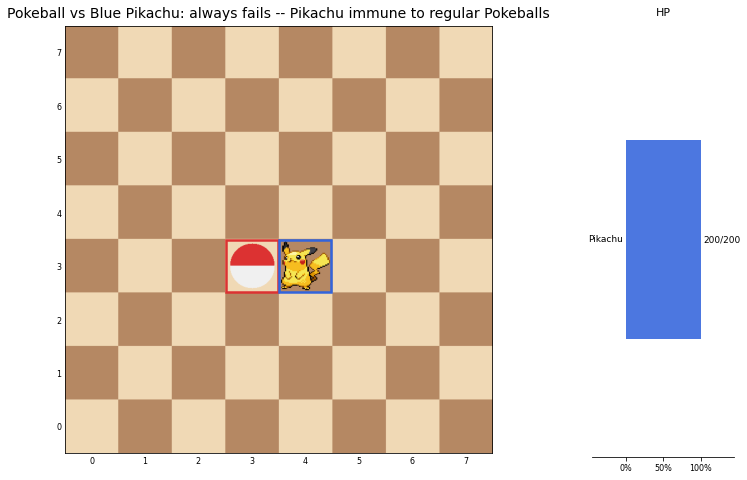

In [13]:
# --- Scenario A: Pokeball vs Squirtle (two outcomes at p=0.5) ---
pb_d = empty_state()
place(pb_d, PieceType.PIKACHU,  Team.RED,  0, 4)
place(pb_d, PieceType.EEVEE,    Team.BLUE, 7, 4)
place(pb_d, PieceType.POKEBALL, Team.RED,  3, 3)
place(pb_d, PieceType.SQUIRTLE, Team.BLUE, 3, 4)

outcomes = apply_move(pb_d, Move(3, 3, ActionType.ATTACK, 3, 4))
# Sort so capture is first
outcomes.sort(key=lambda x: -x[1])  # p=0.5 both; order may vary — sort by whether Squirtle is gone
capture_ns = next(ns for ns, _ in outcomes if ns.board[3][4] and ns.board[3][4].team == Team.RED)
fail_ns    = next(ns for ns, _ in outcomes if not (ns.board[3][4] and ns.board[3][4].team == Team.RED))

print('Pokeball vs Squirtle: 2 outcomes at p=0.5 each')
for ns, prob in outcomes:
    sq = ns.board[3][4]
    print(f'  p={prob:.1f}: {"Capture -- Pokeball occupies (3,4)" if sq and sq.team==Team.RED else "Fail -- Squirtle survives"}')

# --- Scenario B: Pokeball vs Pikachu (immune) — separate board, no Red Pikachu king ---
pika_d = empty_state()
place(pika_d, PieceType.POKEBALL, Team.RED,  3, 3)
place(pika_d, PieceType.PIKACHU,  Team.BLUE, 3, 4)
pika_outcomes = apply_move(pika_d, Move(3, 3, ActionType.ATTACK, 3, 4))
print(f'\nPokeball vs Blue Pikachu: {len(pika_outcomes)} outcome (p=1.0) -- Pikachu is immune')

show_states([
    (pb_d,      'Before: Red Pokeball targets Blue Squirtle at (3,4)'),
    (capture_ns,'Outcome A (p=0.5): Capture -- Pokeball occupies (3,4)'),
    (fail_ns,   'Outcome B (p=0.5): Capture failed -- Squirtle survives'),
], show_hp=True)

show_states([
    (pika_d, 'Pokeball vs Blue Pikachu: always fails -- Pikachu immune to regular Pokeballs'),
], show_hp=True)

---
## Section 8 — Foresight (Mew)

Foresight schedules delayed damage that resolves at the **start of the caster's next turn** (2 half-moves later). Cannot be cast on consecutive turns.

In [14]:
fs = empty_state(turn=1)
place(fs, PieceType.PIKACHU,  Team.RED,  0, 4)
place(fs, PieceType.EEVEE,    Team.BLUE, 7, 4)
place(fs, PieceType.MEW,      Team.RED,  3, 3)
place(fs, PieceType.SQUIRTLE, Team.BLUE, 5, 5)

sq_hp = fs.board[5][5].current_hp

# Turn 1: Mew casts Foresight on (5,5)
fs1 = apply_det(fs, 3, 3, ActionType.FORESIGHT, 5, 5)
fx  = fs1.pending_foresight[Team.RED]

# Turn 2: Blue moves king
fs2 = apply_det(fs1, 7, 4, ActionType.MOVE, 6, 4)

# Turn 3: Red moves king -- Foresight resolves at start of RED's turn
fs3 = apply_det(fs2, 0, 4, ActionType.MOVE, 0, 3)
sq_a   = fs3.board[5][5]
result = 'KO' if sq_a is None else f'HP {sq_a.current_hp}/{sq_hp}'

print(f'Foresight: damage={fx.damage}, resolves_on_turn={fx.resolves_on_turn}')
print(f'Squirtle result after resolution: {result}')

show_states([
    (fs,  'Turn 1: Mew at (3,3) and Blue Squirtle at (5,5)'),
    (fs1, f'Turn 1 done: Foresight cast -- damage={fx.damage}, resolves turn {fx.resolves_on_turn}'),
    (fs2, 'Turn 2: Blue moves -- Foresight still pending'),
    (fs3, f'Turn 3: Foresight resolves -- Squirtle {result}'),
], show_hp=True)

Foresight: damage=120, resolves_on_turn=3
Squirtle result after resolution: HP 80/200


---
## Section 9 — King Evolution

Evolution costs a turn. HP increases by the **HP delta** (evolved max HP − base max HP). An injured king also gains the full delta, not just capped at the new max.

In [15]:
pi_max  = PIECE_STATS[PieceType.PIKACHU].max_hp
ra_max  = PIECE_STATS[PieceType.RAICHU].max_hp
ee_max  = PIECE_STATS[PieceType.EEVEE].max_hp
vap_max = PIECE_STATS[PieceType.VAPOREON].max_hp

# --- Pair 1: Pikachu (full HP) -> Raichu ---
ev1 = empty_state()
p1 = place(ev1, PieceType.PIKACHU, Team.RED, 4, 4)
ev1b = apply_det(ev1, 4, 4, ActionType.EVOLVE, 4, 4)
r1 = ev1b.board[4][4]
print(f'Full Pikachu ({pi_max}/{pi_max}) -> Raichu: {r1.current_hp}/{ra_max}  (+{ra_max-pi_max} delta)')
show_states([
    (ev1,  f'Pikachu ({pi_max}/{pi_max} HP) -- before evolution'),
    (ev1b, f'Raichu: {r1.current_hp}/{ra_max} HP  (+{ra_max-pi_max} delta)'),
], show_hp=True)

# --- Pair 2: Pikachu (injured at 80 HP) -> Raichu ---
ev2 = empty_state()
p2 = place(ev2, PieceType.PIKACHU, Team.RED, 4, 4); p2.current_hp = 80
ev2b = apply_det(ev2, 4, 4, ActionType.EVOLVE, 4, 4)
r2 = ev2b.board[4][4]
print(f'Injured Pikachu (80/{pi_max}) -> Raichu: {r2.current_hp}/{ra_max}  (80 + {ra_max-pi_max} delta)')
show_states([
    (ev2,  f'Pikachu (80/{pi_max} HP injured) -- before evolution'),
    (ev2b, f'Raichu: {r2.current_hp}/{ra_max} HP  (80 + {ra_max-pi_max} delta)'),
], show_hp=True)

# --- Pair 3: Eevee -> Vaporeon ---
ev3 = empty_state(active=Team.BLUE)
p3 = place(ev3, PieceType.EEVEE, Team.BLUE, 4, 4); p3.held_item = Item.WATERSTONE
ev3b = apply_det(ev3, 4, 4, ActionType.EVOLVE, 4, 4, move_slot=0)
v = ev3b.board[4][4]
print(f'Eevee ({ee_max}/{ee_max}) + WATERSTONE -> Vaporeon: {v.current_hp}/{vap_max}  (+{vap_max-ee_max} delta)')
show_states([
    (ev3,  f'Eevee ({ee_max}/{ee_max} HP) with WATERSTONE -- before evolution'),
    (ev3b, f'Vaporeon: {v.current_hp}/{vap_max} HP  (+{vap_max-ee_max} delta, stone consumed)'),
], show_hp=True)

Full Pikachu (200/200) -> Raichu: 250/250  (+50 delta)


Injured Pikachu (80/200) -> Raichu: 130/250  (80 + 50 delta)


Eevee (120/120) + WATERSTONE -> Vaporeon: 220/220  (+100 delta)


---
## Section 10 — Win Condition and HP Tiebreaker

Game ends when a king is eliminated. Tiebreaker: total HP across all pieces, where **Pokeball = 50** and **Masterball = 200** (fixed values, not their actual HP which is 0).

Both kings alive: terminal=False
Blue king removed: terminal=True, winner=RED


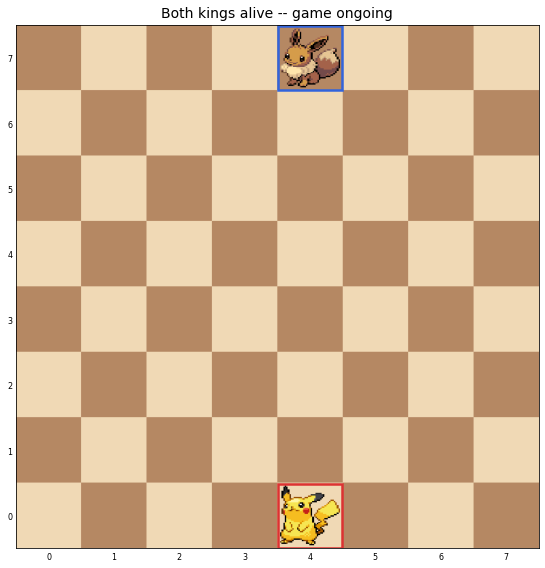

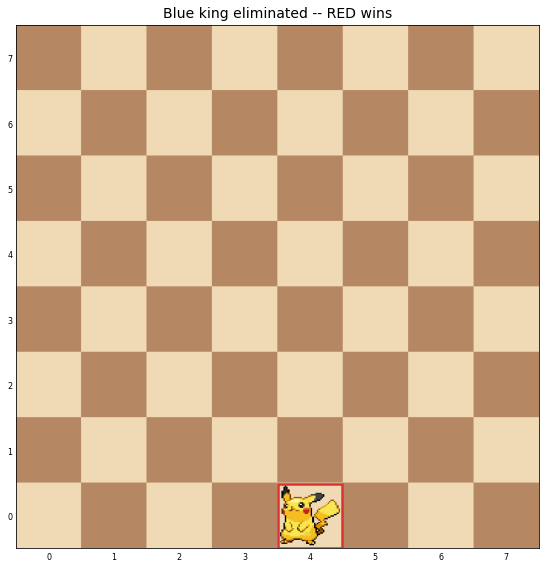


HP tiebreaker:
  RED:  Squirtle(80) + Pokeball(50) = 130
  BLUE: Masterball(200) + Squirtle(60) = 260
  Winner: BLUE


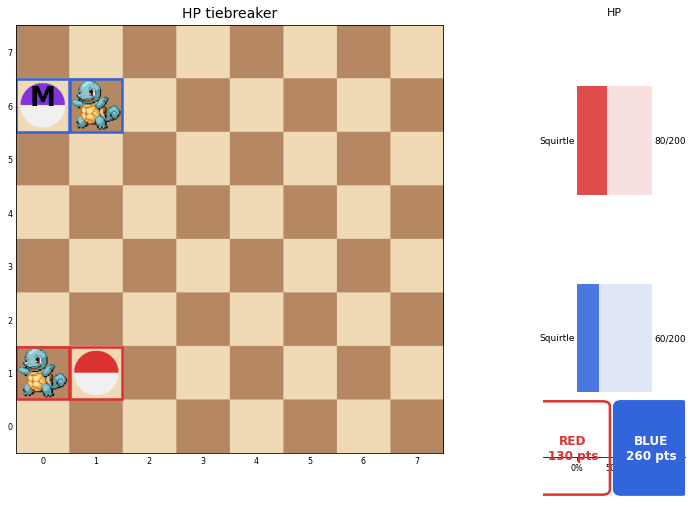

In [16]:
# Win condition
w = empty_state()
place(w, PieceType.PIKACHU, Team.RED,  0, 4)
place(w, PieceType.EEVEE,   Team.BLUE, 7, 4)
done, winner = is_terminal(w)
print(f'Both kings alive: terminal={done}')

w2 = w.copy(); w2.board[7][4] = None
done2, winner2 = is_terminal(w2)
print(f'Blue king removed: terminal={done2}, winner={winner2.name}')

render_board(w,  title='Both kings alive -- game ongoing')
render_board(w2, title='Blue king eliminated -- RED wins')

# HP tiebreaker
hp_s = empty_state()
r_sq = place(hp_s, PieceType.SQUIRTLE,  Team.RED,  1, 0); r_sq.current_hp = 80
place(hp_s, PieceType.POKEBALL,   Team.RED,  1, 1)    # counts as 50
place(hp_s, PieceType.MASTERBALL, Team.BLUE, 6, 0)    # counts as 200
b_sq = place(hp_s, PieceType.SQUIRTLE, Team.BLUE, 6, 1); b_sq.current_hp = 60

red_score  = 80 + 50    # Squirtle HP + Pokeball fixed
blue_score = 200 + 60   # Masterball fixed + Squirtle HP
print(f'\nHP tiebreaker:')
print(f'  RED:  Squirtle(80) + Pokeball(50) = {red_score}')
print(f'  BLUE: Masterball(200) + Squirtle(60) = {blue_score}')
winner_team = hp_winner(hp_s)
print(f'  Winner: {winner_team.name}')

fig = plt.figure(figsize=(12, 8))
gs  = fig.add_gridspec(1, 2, width_ratios=[3, 1], wspace=0.35)
ax_b = fig.add_subplot(gs[0])
ax_h = fig.add_subplot(gs[1])
render_board(hp_s, title='HP tiebreaker', ax=ax_b)
render_hp_bars(hp_s, ax_h)

# Score totals panel below the hp bars
red_col  = '#DC3232'
blue_col = '#3264DC'
ax_s = fig.add_axes([ax_h.get_position().x0, 0.05,
                     ax_h.get_position().width, 0.18])
ax_s.axis('off')
# Draw score boxes; winner gets a solid color box
for xi, (label, score, col, is_winner) in enumerate([
        (f'RED\n{red_score} pts',  red_score,  red_col,  winner_team == Team.RED),
        (f'BLUE\n{blue_score} pts', blue_score, blue_col, winner_team == Team.BLUE),
]):
    fc = col if is_winner else 'none'
    tc = 'white' if is_winner else col
    ax_s.add_patch(mpatches.FancyBboxPatch(
        (xi * 0.55, 0.1), 0.42, 0.8,
        boxstyle='round,pad=0.05', lw=2.5,
        edgecolor=col, facecolor=fc, transform=ax_s.transAxes))
    ax_s.text(xi * 0.55 + 0.21, 0.5, label,
              ha='center', va='center', fontsize=12, fontweight='bold',
              color=tc, transform=ax_s.transAxes)

plt.tight_layout()
plt.show()

---
## Section 11 — Mini Game: 20 Random Moves

Random move selection from the starting position. Use the slider to replay every board state.

In [17]:
import random
random.seed(42)

game = GameState.new_game()
game_states = [(game, 'Turn 1 — Starting position')]

for _ in range(20):
    done, winner = is_terminal(game)
    if done:
        break
    moves = get_legal_moves(game)
    if not moves:
        break
    move = random.choice(moves)
    outcomes = apply_move(game, move)
    game = random.choices([s for s, _ in outcomes], weights=[p for _, p in outcomes])[0]
    team_played = 'RED' if game.active_player == Team.BLUE else 'BLUE'
    label = (f'Turn {game.turn_number}  |  {team_played} played '
             f'{move.action_type.name} ({move.piece_row},{move.piece_col})->'
             f'({move.target_row},{move.target_col})')
    game_states.append((game, label))

done, winner = is_terminal(game)
if done:
    last_s, last_l = game_states[-1]
    game_states[-1] = (last_s, last_l + f'\n★ GAME OVER — {winner.name if winner else "DRAW"} wins')

print(f'{len(game_states)} states. Use the slider to replay.')
show_states(game_states)


21 states. Use the slider to replay.


---
## Section 12 — Playable Game

Click any piece belonging to the active player to see its legal moves:

- **Yellow** — move destinations
- **Orange** — attack targets
- **Cyan** — Foresight targets (Mew / Espeon)
- **Red ✗** — squares blocked by your own pieces

Click any highlighted square to execute the move.

**Controls**
- *Mew move* toggle — choose which of Mew's 3 typed attacks to use before clicking a target
- *Foresight mode* checkbox — click a cyan square to schedule a delayed attack instead of moving
- *Undo* — step back one half-move
- *New Game* — reset to the starting position

**Modes**
`PokeChessGame('hvh')` — human vs human
`PokeChessGame('hvb')` — human (RED) vs random bot (BLUE)
`PokeChessGame('bvh')` — random bot (RED) vs human (BLUE)

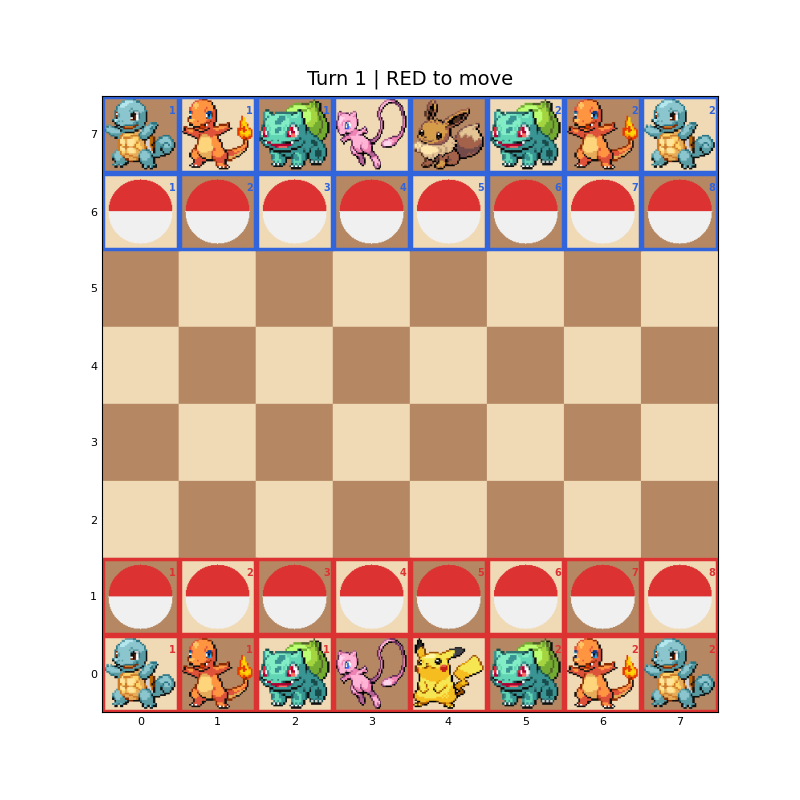

In [19]:
%matplotlib widget
import random as _rand

class PokeChessGame:
    """Interactive PokeChess game.

    mode: 'hvh' (human vs human), 'hvb' (human=RED, bot=BLUE), 'bvh' (bot=RED, human=BLUE).
    Click a piece to select it and see its moves. Click a highlighted square to move.
    """

    def __init__(self, mode='hvh'):
        self.mode    = mode
        self.state   = GameState.new_game()
        self.history = []
        self.selected     = None   # (row, col) of selected piece, or None
        self._legal_all   = []
        self._legal_piece = []
        self._pending     = []     # moves awaiting disambiguation

        # ── Mew slot selector ──────────────────────────────────────────────
        self._mew_dd = widgets.ToggleButtons(
            options=[('Fire Blast', 0), ('Hydro Pump', 1), ('Solar Beam', 2)],
            value=0,
            description='Mew move:',
            button_style='',
            style={'button_width': '110px', 'description_width': '90px'},
            layout=widgets.Layout(visibility='hidden'),
        )

        # ── Foresight mode toggle ──────────────────────────────────────────
        self._fs_chk = widgets.Checkbox(
            value=False, description='Foresight mode',
            disabled=True, indent=False,
            layout=widgets.Layout(width='160px'),
        )
        self._fs_chk.observe(self._on_fs_toggle, names='value')

        # ── Disambiguation bar ─────────────────────────────────────────────
        self._disambig_dd  = widgets.Dropdown(
            description='Choose:',
            layout=widgets.Layout(width='400px', visibility='hidden'))
        self._disambig_btn = widgets.Button(
            description='Confirm', button_style='success',
            layout=widgets.Layout(width='100px', visibility='hidden'))
        self._disambig_btn.on_click(self._on_disambig_confirm)

        # ── Status / last move ─────────────────────────────────────────────
        self._status  = widgets.HTML()
        self._last_mv = widgets.HTML()
        self._undo_btn  = widgets.Button(description='⬅ Undo',  button_style='warning',
                                         layout=widgets.Layout(width='90px'))
        self._reset_btn = widgets.Button(description='New Game', button_style='danger',
                                         layout=widgets.Layout(width='90px'))
        self._undo_btn.on_click(self._on_undo)
        self._reset_btn.on_click(self._on_reset)

        # ── Figure ─────────────────────────────────────────────────────────
        self.fig, self.ax = plt.subplots(figsize=(8, 8))
        self.fig.canvas.toolbar_visible = False
        self.fig.canvas.header_visible  = False
        self.fig.canvas.footer_visible  = False
        self.fig.canvas.mpl_connect('button_press_event', self._on_click)

        ui = widgets.VBox([
            widgets.HBox([self._status, self._undo_btn, self._reset_btn]),
            widgets.HBox([self._mew_dd, self._fs_chk]),
            widgets.HBox([self._disambig_dd, self._disambig_btn]),
            self._last_mv,
        ])
        display(widgets.VBox([self.fig.canvas, ui]))
        self._refresh()

    # ── Helpers ───────────────────────────────────────────────────────────────

    def _is_human_turn(self):
        p = self.state.active_player
        if self.mode == 'hvh':  return True
        if self.mode == 'hvb':  return p == Team.RED
        if self.mode == 'bvh':  return p == Team.BLUE
        return True

    def _move_label(self, m):
        _mew_names = {0: 'Fire Blast', 1: 'Hydro Pump', 2: 'Solar Beam'}
        at, t = m.action_type, f'({m.target_row},{m.target_col})'
        if at == ActionType.QUICK_ATTACK:
            return f'Quick Attack →{t} then ({m.secondary_row},{m.secondary_col})'
        if at == ActionType.ATTACK and m.move_slot is not None:
            return f'{_mew_names.get(m.move_slot,"?")} →{t}'
        if at == ActionType.FORESIGHT:
            return f'Foresight →{t}'
        if at == ActionType.EVOLVE:
            return 'Evolve'
        if at == ActionType.TRADE:
            p2 = self.state.board[m.target_row][m.target_col]
            return f'Trade with {p2.piece_type.name.title()} at {t}'
        return f'{at.name.title()} →{t}'

    # ── Click handler ─────────────────────────────────────────────────────────

    def _on_click(self, event):
        if event.inaxes != self.ax or event.xdata is None:
            return
        col = int(event.xdata // CELL)
        row = 7 - int(event.ydata // CELL)
        if not (0 <= row < 8 and 0 <= col < 8):
            return
        done, _ = is_terminal(self.state)
        if done or not self._is_human_turn():
            return

        p = self.state.board[row][col]

        if self.selected is None:
            if p is not None and p.team == self.state.active_player:
                self._select(row, col)
            return

        sel_r, sel_c = self.selected

        # Gather moves that target clicked square
        candidates = [m for m in self._legal_piece
                      if m.target_row == row and m.target_col == col]

        # Filter by foresight / normal mode
        if self._fs_chk.value:
            candidates = [m for m in candidates if m.action_type == ActionType.FORESIGHT]
        else:
            candidates = [m for m in candidates if m.action_type != ActionType.FORESIGHT]

        # Filter by Mew slot when applicable
        piece = self.state.board[sel_r][sel_c]
        if (candidates and piece is not None
                and piece.piece_type == PieceType.MEW
                and candidates[0].action_type == ActionType.ATTACK):
            slot = self._mew_dd.value
            candidates = [m for m in candidates
                          if m.move_slot is None or m.move_slot == slot]

        if len(candidates) == 1:
            self._execute_move(candidates[0])
        elif len(candidates) > 1:
            self._show_disambig(candidates)
        elif p is not None and p.team == self.state.active_player:
            self._select(row, col)   # switch to another friendly piece
        else:
            self._deselect()
            self._redraw()

    # ── Selection ─────────────────────────────────────────────────────────────

    def _select(self, row, col):
        self.selected = (row, col)
        p = self.state.board[row][col]
        self._legal_piece = [m for m in self._legal_all
                             if m.piece_row == row and m.piece_col == col]
        foresight_capable = p.piece_type in (PieceType.MEW, PieceType.ESPEON)
        self._mew_dd.layout.visibility = (
            'visible' if p.piece_type == PieceType.MEW else 'hidden')
        self._fs_chk.disabled = not foresight_capable
        if not foresight_capable:
            self._unobserved_fs_reset()
        self._redraw()

    def _deselect(self):
        self.selected = None
        self._legal_piece = []
        self._pending = []
        self._mew_dd.layout.visibility = 'hidden'
        self._unobserved_fs_reset()
        self._fs_chk.disabled = True
        self._disambig_dd.layout.visibility = 'hidden'
        self._disambig_btn.layout.visibility = 'hidden'

    def _unobserved_fs_reset(self):
        """Reset foresight checkbox without triggering the observer."""
        self._fs_chk.unobserve(self._on_fs_toggle, names='value')
        self._fs_chk.value = False
        self._fs_chk.observe(self._on_fs_toggle, names='value')

    def _on_fs_toggle(self, _change):
        self._redraw()

    # ── Disambiguation ────────────────────────────────────────────────────────

    def _show_disambig(self, moves):
        self._pending = moves
        self._disambig_dd.options = [(self._move_label(m), i) for i, m in enumerate(moves)]
        self._disambig_dd.value   = 0
        self._disambig_dd.layout.visibility  = 'visible'
        self._disambig_btn.layout.visibility = 'visible'

    def _on_disambig_confirm(self, _):
        idx = self._disambig_dd.value
        if self._pending and idx is not None and idx < len(self._pending):
            move = self._pending[idx]
            self._disambig_dd.layout.visibility  = 'hidden'
            self._disambig_btn.layout.visibility = 'hidden'
            self._pending = []
            self._execute_move(move)

    # ── Move execution ────────────────────────────────────────────────────────

    def _execute_move(self, move):
        prev_player = self.state.active_player
        self.history.append(self.state)
        outcomes = apply_move(self.state, move)
        self.state = _rand.choices(
            [s for s, _ in outcomes], weights=[p for _, p in outcomes])[0]
        prob = f' (p={outcomes[0][1]:.0%})' if len(outcomes) > 1 else ''
        self._last_mv.value = (
            f'<small><b>{prev_player.name}:</b> {self._move_label(move)}{prob}</small>')
        self._deselect()
        self._refresh()

    # ── Refresh / redraw ──────────────────────────────────────────────────────

    def _refresh(self):
        done, winner = is_terminal(self.state)
        if done:
            if winner:
                col = '#c00' if winner == Team.RED else '#00c'
                self._status.value = (
                    f'<b style="color:{col}">★ {winner.name} wins!</b>')
            else:
                self._status.value = '<b>★ Draw</b>'
            self._legal_all = []
        else:
            self._legal_all = get_legal_moves(self.state)
            player = self.state.active_player
            col    = '#c00' if player == Team.RED else '#00c'
            who    = 'your turn' if self._is_human_turn() else 'bot…'
            self._status.value = (
                f'<b style="color:{col}">{"RED" if player == Team.RED else "BLUE"}'
                f' to move</b> <small>({who})</small>')
        self._redraw()
        if not done and not self._is_human_turn():
            self._bot_move()

    def _redraw(self):
        sel = self.selected
        hl_move = []; hl_atk = []; hl_fs = []
        if sel:
            for m in self._legal_piece:
                sq = (m.target_row, m.target_col)
                if m.action_type == ActionType.FORESIGHT:
                    hl_fs.append(sq)
                elif m.action_type in (ActionType.ATTACK, ActionType.QUICK_ATTACK):
                    hl_atk.append(sq)
                else:
                    hl_move.append(sq)
        blocked = get_friendly_blocked(self.state, *sel) if sel else []
        title   = (f'Turn {self.state.turn_number} '
                   f'| {self.state.active_player.name} to move')
        self.ax.cla()
        render_board(self.state,
                     highlight=hl_move,
                     highlight_attacks=hl_atk,
                     highlight_foresight=hl_fs,
                     piece_sq=sel,
                     blocked_sqs=blocked,
                     title=title, ax=self.ax)
        self.fig.canvas.draw_idle()

    # ── Bot ───────────────────────────────────────────────────────────────────

    def _bot_move(self):
        moves = get_legal_moves(self.state)
        if not moves:
            return
        move = _rand.choice(moves)
        prev_player = self.state.active_player
        self.history.append(self.state)
        outcomes = apply_move(self.state, move)
        self.state = _rand.choices(
            [s for s, _ in outcomes], weights=[p for _, p in outcomes])[0]
        self._last_mv.value = (
            f'<small><b>BOT ({prev_player.name}):</b> {self._move_label(move)}</small>')
        self._refresh()

    # ── Undo / Reset ──────────────────────────────────────────────────────────

    def _on_undo(self, _):
        if self.history:
            self.state = self.history.pop()
            self._deselect()
            self._refresh()

    def _on_reset(self, _):
        self.state = GameState.new_game()
        self.history.clear()
        self._deselect()
        self._refresh()


# ── Launch ────────────────────────────────────────────────────────────────────
# Human vs human:
game = PokeChessGame('hvh')

# Human (RED) vs random bot (BLUE) — uncomment to use:
# game = PokeChessGame('hvb')
